### Dataset

In [1]:
import pandas as pd
# Load the dataset *** I used the parameter low_memory because the size of the file
df = pd.read_csv('citibike.csv', low_memory=False)
df.info(verbose=True,max_cols=12)

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 99.2 MB


### Handling Nulls

In [2]:
# count of nulls per column
print(df.isnull().sum())
print('='*40)

# percentage of nulls
print((df.isnull().sum() / len(df)) * 100)

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     903
start_station_id       903
end_station_name      3885
end_station_id        5047
start_lat              903
start_lng              903
end_lat               5003
end_lng               5003
member_casual            0
dtype: int64


ride_id               0.0000
rideable_type         0.0000
started_at            0.0000
ended_at              0.0000
start_station_name    0.0903
start_station_id      0.0903
end_station_name      0.3885
end_station_id        0.5047
start_lat             0.0903
start_lng             0.0903
end_lat               0.5003
end_lng               0.5003
member_casual         0.0000
dtype: float64


#### Imputing
##### This script creates a dictionary that maps each station name to its average geographic coordinates found elsewhere in the dataset

In [3]:
# build the reference map
# take all rows that have coordinates and group them by station name
reference_data = df.dropna(subset=['end_lat', 'end_lng', 'end_station_name'])
coords_map = reference_data.groupby('end_station_name')[['end_lat', 'end_lng']].mean().to_dict()

# extract individual maps for lat and lng
lat_map = coords_map['end_lat']
lng_map = coords_map['end_lng']

# count missing values
print(f"Nulls in end_lat before: {df['end_lat'].isnull().sum()}")

# apply the Imputation
# It only fills nulls where the 'end_station_name' provides a match in our map
df['end_lat'] = df['end_lat'].fillna(df['end_station_name'].map(lat_map))
df['end_lng'] = df['end_lng'].fillna(df['end_station_name'].map(lng_map))

# Checking the improvement
print(f"Nulls in end_lat after: {df['end_lat'].isnull().sum()}")

Nulls in end_lat before: 5003


Nulls in end_lat after: 3841


##### we can use the end_station_id to fill missing end_station_names, and vice versa

In [4]:
# Now build the Knowledge Base
# select rows where both name and Id exist to create our mapping dictionaries
ref_df = df.dropna(subset=['end_station_name', 'end_station_id'])

# create a map to find the Name if I have the ID
id_to_name_map = ref_df.drop_duplicates('end_station_id').set_index('end_station_id')['end_station_name'].to_dict()

# Create a map to find the ID if I have the Name
name_to_id_map = ref_df.drop_duplicates('end_station_name').set_index('end_station_name')['end_station_id'].to_dict()

# apply the Imputation
# Fill missing Names by looking up the Id
df['end_station_name'] = df['end_station_name'].fillna(df['end_station_id'].map(id_to_name_map))

# Fill missing Ids by looking up the Name
df['end_station_id'] = df['end_station_id'].fillna(df['end_station_name'].map(name_to_id_map))

# Check results
print(f"Remaining null names: {df['end_station_name'].isnull().sum()}")
print(f"Remaining null IDs: {df['end_station_id'].isnull().sum()}")

Remaining null names: 3885
Remaining null IDs: 3885


In [5]:
# modified dataset
print((df.isnull().sum() / len(df)) * 100)

ride_id               0.0000
rideable_type         0.0000
started_at            0.0000
ended_at              0.0000
start_station_name    0.0903
start_station_id      0.0903
end_station_name      0.3885
end_station_id        0.3885
start_lat             0.0903
start_lng             0.0903
end_lat               0.3841
end_lng               0.3841
member_casual         0.0000
dtype: float64

##### Drop any row with at least one null

In [6]:
# new cleaned dataset
df_cleaned = df.dropna()
print((df_cleaned.isnull().sum() / len(df)) * 100)


ride_id               0.0
rideable_type         0.0
started_at            0.0
ended_at              0.0
start_station_name    0.0
start_station_id      0.0
end_station_name      0.0
end_station_id        0.0
start_lat             0.0
start_lng             0.0
end_lat               0.0
end_lng               0.0
member_casual         0.0
dtype: float64


### Filter Ghost Trips
##### This process involves converting the timestamp strings into datetime objects to perform arithmetic, then creating a mask to remove the noise

In [7]:
# convert to datetime to calculate duration
df_cleaned['started_at'] = pd.to_datetime(df_cleaned['started_at'])
df_cleaned['ended_at'] = pd.to_datetime(df_cleaned['ended_at'])

# calculate trip duration in seconds
df_cleaned['duration_sec'] = (df_cleaned['ended_at'] - df_cleaned['started_at']).dt.total_seconds()

# define the filtering logic
# rule 1: Must have a duration greater than zero
# rule 2: If the start and end stations are the same,
# it must last longer than 60 seconds to be considered a real trip
is_ghost_trip = (
    (df_cleaned['duration_sec'] <= 0) |
    ((df_cleaned['start_station_id'] == df_cleaned['end_station_id']) & (df_cleaned['duration_sec'] < 60))
)

# apply the filter
# keep only the rows that are not ghost trips (using symbol ~)
df_cleaned_new = df_cleaned[~is_ghost_trip].copy()

# report the findings
removed_count = len(df_cleaned) - len(df_cleaned_new)
print(f"Removed {removed_count} Ghost Trips from the dataset.")


Removed 0 Ghost Trips from the dataset.


### Deduplication
##### process of identifying and removing redundant records

In [8]:
duplicate_count = df_cleaned.duplicated(subset=['ride_id']).sum()
print(f"Number of duplicate ride_ids: {duplicate_count}")

if duplicate_count > 0:
    print(df_cleaned[df_cleaned.duplicated(subset=['ride_id'], keep=False)].sort_values('ride_id').head())

Number of duplicate ride_ids: 0


##### sometimes, two records have different ride_ids but represent the same real-world event (Logical duplicates)

In [9]:
logical_dupes = df_cleaned.duplicated(subset=['started_at', 'start_station_id', 'rideable_type'], keep=False)

print(f"Potential logical duplicates: {logical_dupes.sum()}")

Potential logical duplicates: 0


### Feature Transformation
##### We have to treat the timestamp strings as actual datetime objects

In [10]:
import numpy as np
# convert strings to datetime objects
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])


### Calculating Trip Duration
##### the length of a trip is often the strongest indicator of user behavior

In [11]:
# calculate duration in minutes
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# checking the first few values
print(df[['started_at', 'ended_at', 'duration_min']].head())

               started_at                ended_at  duration_min
0 2026-02-06 17:20:08.324 2026-02-06 17:24:21.584      4.221000
1 2026-02-04 12:02:28.817 2026-02-04 12:10:27.340      7.975383
2 2026-02-11 19:37:21.253 2026-02-11 19:43:18.957      5.961733
3 2026-02-01 12:31:54.323 2026-02-01 12:39:24.020      7.494950
4 2026-02-13 05:49:37.127 2026-02-13 06:09:27.904     19.846283


##### We break the timestamp into simple integers. This helps the model identify patterns like "morning rushes" or "weekend peaks"

In [12]:
# extract hour (0-23)
df['hour'] = df['started_at'].dt.hour

# extract day of week [ 0 = monday ]
df['day_of_week'] = df['started_at'].dt.dayofweek

# extract day of month
df['day_of_month'] = df['started_at'].dt.day

# checking the first few values
print(df[['hour', 'day_of_week', 'day_of_month']].head())

   hour  day_of_week  day_of_month
0    17            4             6
1    12            2             4
2    19            2            11
3    12            6             1
4     5            4            13


### Creating Binary Indicators (Flags)
##### create specific "flags" for known business patterns like weekends and peak commuting hours

In [13]:
# is it a weekend? (5 = Saturday or 6 = Sunday)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# is it peak commuting hours? (for instance 7-9 and 14-19)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# checking the first few values
print(df[['is_weekend', 'is_rush_hour']].head())

   is_weekend  is_rush_hour
0           0             1
1           0             0
2           0             1
3           1             0
4           0             0


### Cyclical Time
#####  To help the model understand that hour 23 is close to hour 0, we will use sine/cosine transformations

In [14]:
# 24 hours in a day
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Now, hour 23 and hour 0 will be mathematically close in the vector space
# checking the first few values
print(df[['hour_sin','hour_cos']].head())

       hour_sin  hour_cos
0 -9.659258e-01 -0.258819
1  1.224647e-16 -1.000000
2 -9.659258e-01  0.258819
3  1.224647e-16 -1.000000
4  9.659258e-01  0.258819


### Categorical Encoding
##### It is the process of translating labels into a numerical format that preserves the information's meaning
##### The task is to convert rideable_type (Electric vs. Classic) and member_casual into 0 and 1

In [15]:
# encode member_casual [ member = 1, casual = 0 ]
df['is_member'] = df['member_casual'].map({'member': 1, 'casual': 0})

# encode 'rideable_type' [ electric_bike = 1, classic_bike = 0 ]
df['is_electric'] = df['rideable_type'].map({'electric_bike': 1, 'classic_bike': 0})

print(df[['is_member', 'is_electric']].head())

   is_member  is_electric
0          1            1
1          1            1
2          1            1
3          1            1
4          1            0


### Frequency Encoding
##### This replaces the station name with the number of times it appears in the dataset. This captures the "popularity" of a station as a numerical signal

In [16]:
# frequency of each start station
station_freq = df['start_station_name'].value_counts()

# mapping the frequencies back to the dataframe
df['start_station_popularity'] = df['start_station_name'].map(station_freq)

print(df[['start_station_name', 'start_station_popularity']].head())

        start_station_name  start_station_popularity
0      Bond St & Bergen St                     479.0
1  Norman Ave & Leonard St                     857.0
2           E 2 St & Ave C                    1527.0
3  St James Pl & Oliver St                    1284.0
4          W 20 St & 7 Ave                    2002.0


### Label Encoding
##### Thinking in doing clustering (unsupervised learning) later, we just want a unique integer for each station

In [17]:
# we will use the categorical type in pandas to get codes
df['station_id_encoded'] = df['start_station_name'].astype('category').cat.codes

print(df[['station_id_encoded']].head())


   station_id_encoded
0                 631
1                1618
2                1035
3                1853
4                2022


### Normalization and Scaling
##### Since start_lat, start_lng, and duration have different units, we are going to apply Standardization to give them a mean of 0 and a standard deviation of 1

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df['duration_min'] = (pd.to_datetime(df['ended_at']) - pd.to_datetime(df['started_at'])).dt.total_seconds() / 60

# columns to scale
cols_to_scale = ['duration_min', 'start_lat', 'start_lng']

# applying Standardization (Z-score)
scaler_std = StandardScaler()
df[cols_to_scale] = scaler_std.fit_transform(df[cols_to_scale])

# Now your duration, latitude, and longitude are all on a
# similar mathematical footing (centered around 0)
print(df[cols_to_scale].describe())

       duration_min     start_lat     start_lng
count  1.000000e+06  9.990970e+05  9.990970e+05
mean   1.818989e-18  6.948265e-14 -2.939959e-14
std    1.000001e+00  1.000001e+00  1.000001e+00
min   -2.932891e-01 -3.206422e+00 -2.457196e+00
25%   -1.823454e-01 -5.911288e-01 -7.046120e-01
50%   -9.860970e-02 -5.074383e-03 -2.625713e-01
75%    3.996420e-02  5.865997e-01  5.871792e-01
max    4.097339e+01  3.840520e+00  4.519964e+00


### Addressing Data Imbalance


In [19]:
# getting the Raw Counts
counts = df['member_casual'].value_counts()

# get the percentages ->> Relative Frequency
# setting normalize=True gives us the proportion (0.0 to 1.0)
percentages = df['member_casual'].value_counts(normalize=True) * 100

# the results
print("== Class Distribution ==")
print(counts)
print("\n== Percentage Distribution ==")
print(percentages.map('{:.2f}%'.format))

== Class Distribution ==
member_casual
member    914503
casual     85497
Name: count, dtype: int64

== Percentage Distribution ==
member_casual
member    91.45%
casual     8.55%
Name: proportion, dtype: str


### Managing Sparsity (Unsupervised Tasks)
### Spatial Binning
##### Instead of using raw coordinates, we group them into bins or grids

In [20]:
# round coordinates to 3 decimal places ( about 110 meters precision)
# this 'bins' nearby rides into the same geographic point
df['lat_bin'] = df['start_lat'].round(3)
df['lng_bin'] = df['start_lng'].round(3)

# now we can cluster based on these 'bins' rather than raw noisy points
print(df[['start_lat','start_lng','lat_bin', 'lng_bin']].head())

   start_lat  start_lng  lat_bin  lng_bin
0  -1.317567  -0.510159   -1.318   -0.510
1  -0.270947   0.766152   -0.271    0.766
2  -0.397647  -0.317239   -0.398   -0.317
3  -0.597338  -0.953866   -0.597   -0.954
4   0.153541  -0.908804    0.154   -0.909


### PCA Dimensionality reduction
##### It finds the directions in the data where the most change occurs and ignores the dimensions where nothing is happening

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# let's prepare numerical/encoded features
features = df[['duration_min', 'hour_sin', 'hour_cos', 'lat_bin', 'lng_bin']].dropna()

# scaling is mandatory before PCA
X_scaled = StandardScaler().fit_transform(features)

# reduce to 2 components for easy 2D visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# create a dataframe with the results
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# checking the result
print(df_pca.head())

        PC1       PC2
0 -1.144387 -1.042180
1  1.120151 -0.010823
2 -1.506538 -0.074126
3  0.719394 -1.400398
4  0.364434 -0.552888


### Finding optimal K
##### we must decide the number of clusters (K) beforehand. We use the Elbow Method to find the point where adding more clusters no longer significantly improves the model's tightness (Inertia).

In [22]:
null_vals=df[['start_lat', 'start_lng', 'hour_sin', 'hour_cos', 'duration_min']].isnull().sum()
print(null_vals)

start_lat       903
start_lng       903
hour_sin          0
hour_cos          0
duration_min      0
dtype: int64


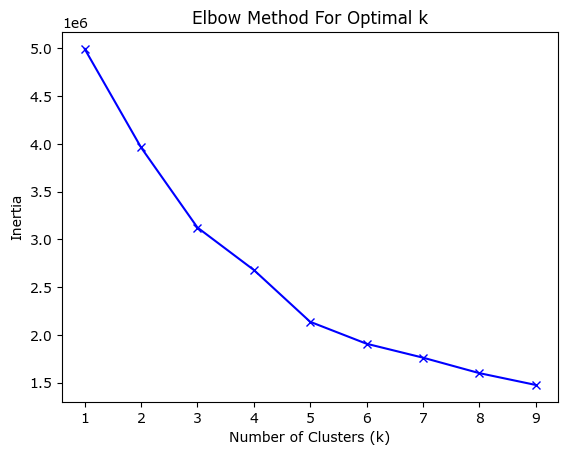

In [23]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# prepare and Scale the data [ Standardization is mandatory for K-Means ]
features = df[['start_lat', 'start_lng', 'hour_sin', 'hour_cos', 'duration_min']].dropna()
X_scaled = StandardScaler().fit_transform(features)

# Elbow Method
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# plot Elbow
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()